# Weibull Distribution

The **Weibull distribution** is the workhorse of reliability engineering. Its shape parameter $\gamma$ makes the hazard function increasing (wear-out), constant (random), or decreasing (infant mortality) — allowing one distribution family to model the entire product lifecycle (bathtub curve).

| Property | Value |
|---|---|
| **Parameters** | $\gamma$ (shape, $\gamma > 0$), $\beta$ (scale, $\beta > 0$), $\mu$ (location) |
| **Support** | $[\mu, +\infty)$ |
| **PDF** | $f(x) = \dfrac{\gamma}{\beta}\left(\dfrac{x-\mu}{\beta}\right)^{\gamma-1} \exp\!\left(-\left(\dfrac{x-\mu}{\beta}\right)^\gamma\right)$ |
| **CDF** | $F(x) = 1 - \exp\!\left(-\left(\dfrac{x-\mu}{\beta}\right)^\gamma\right)$ |
| **Mean** | $\mu + \beta\,\Gamma(1 + 1/\gamma)$ |
| **Hazard** | $h(x) = \dfrac{\gamma}{\beta}\left(\dfrac{x-\mu}{\beta}\right)^{\gamma-1}$ |
| **$\gamma < 1$** | Decreasing hazard — infant mortality |
| **$\gamma = 1$** | Constant hazard — reduces to Exponential |
| **$\gamma > 1$** | Increasing hazard — wear-out failures |
| **$\gamma \approx 3.5$** | Approximates Normal (skewness $\approx 0$) |
| **Estimation** | MLE or Weibull probability plot (ln-ln transform) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Weibull Distribution

### Panel 1 — PDF: Shape Parameter $\gamma$ Controls Form
Each curve shows the **PDF** of $\text{Weibull}(\gamma, \beta=1)$ for different shape values. The shape dramatically changes the distribution: monotone decreasing for $\gamma < 1$, Rayleigh-like for $\gamma=2$, and nearly symmetric for $\gamma \approx 3.5$.

### Panel 2 — Hazard Function $h(x)$
The hazard $h(x) = (\gamma/\beta)(x/\beta)^{\gamma-1}$ is the key reliability diagnostic. It **decreases** for $\gamma < 1$ (infant mortality), stays **constant** for $\gamma=1$ (random failures, i.e. Exponential), and **increases** for $\gamma > 1$ (wear-out failures).

### Panel 3 — Weibull Probability Plot
The linearising transform $\ln(\ln(1/(1-F)))$ vs $\ln(t)$ gives a straight line for Weibull data. The slope of the fitted line estimates the shape $\gamma$; the intercept encodes the scale $\beta$.


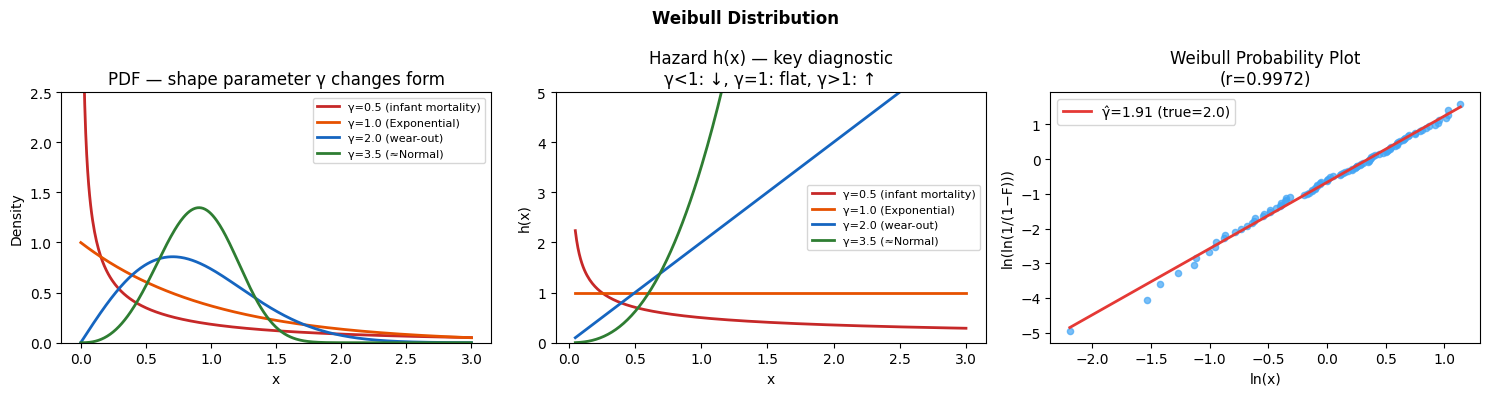

Weibull probability plot estimates: γ̂=1.908 (true=2.0), β̂=1.420 (true=1.5)


In [2]:
x = np.linspace(0.001, 3, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Weibull Distribution', fontsize=12, fontweight='bold')

# scipy uses 'c' for shape (= γ), scale for β
shapes = [(0.5, '#C62828', 'γ=0.5 (infant mortality)'),
          (1.0, '#E65100', 'γ=1.0 (Exponential)'),
          (2.0, '#1565C0', 'γ=2.0 (wear-out)'),
          (3.5, '#2E7D32', 'γ=3.5 (≈Normal)')]

# PDF
for gamma, color, label in shapes:
    axes[0].plot(x, stats.weibull_min(c=gamma, scale=1).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — shape parameter γ changes form')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 2.5)
axes[0].legend(fontsize=8)

# Hazard function
x_h = np.linspace(0.05, 3, 300)
for gamma, color, label in shapes:
    d = stats.weibull_min(c=gamma, scale=1)
    h = d.pdf(x_h) / d.sf(x_h)
    axes[1].plot(x_h, h, color=color, linewidth=2, label=label)
axes[1].set_title('Hazard h(x) — key diagnostic\nγ<1: ↓, γ=1: flat, γ>1: ↑')
axes[1].set_xlabel('x'); axes[1].set_ylabel('h(x)')
axes[1].set_ylim(0, 5)
axes[1].legend(fontsize=8)

# Weibull probability plot
np.random.seed(42)
true_gamma, true_beta = 2.0, 1.5
data = stats.weibull_min(c=true_gamma, scale=true_beta).rvs(100)
t_sorted = np.sort(data)
n = len(t_sorted)
i = np.arange(1, n+1)
F = (i - 0.3) / (n + 0.4)   # Benard's median rank
y = np.log(np.log(1/(1-F)))
x_plot = np.log(t_sorted)
slope, intercept, r, *_ = stats.linregress(x_plot, y)
axes[2].scatter(x_plot, y, color='#42A5F5', s=20, alpha=0.7)
axes[2].plot(x_plot, slope*x_plot + intercept, color='#E53935', linewidth=2,
             label=f'γ̂={slope:.2f} (true={true_gamma})')
axes[2].set_title(f'Weibull Probability Plot\n(r={r:.4f})')
axes[2].set_xlabel('ln(x)'); axes[2].set_ylabel('ln(ln(1/(1−F)))')
axes[2].legend()

plt.tight_layout()
plt.show()

eta_hat = np.exp(-intercept / slope)
print(f"Weibull probability plot estimates: γ̂={slope:.3f} (true={true_gamma}), β̂={eta_hat:.3f} (true={true_beta})")

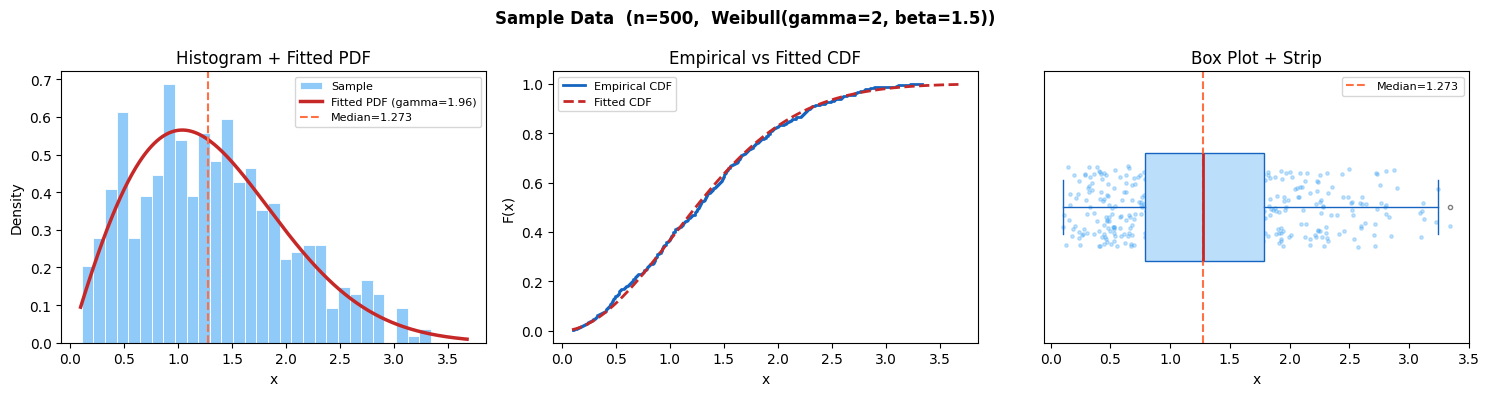

n=500  mean=1.3261  median=1.2726  std=0.7086  skew=0.4621  kurtosis=-0.4132


In [3]:
# Sample data plots — Weibull(gamma=2, beta=1.5)
np.random.seed(42)
sample_d = stats.weibull_min.rvs(c=2, scale=1.5, size=500)
c_hat, loc_hat, scale_hat = stats.weibull_min.fit(sample_d, floc=0)
x_fit = np.linspace(sample_d.min() * 0.9, sample_d.max() * 1.1, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  Weibull(gamma=2, beta=1.5))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.weibull_min(c_hat, loc_hat, scale_hat).pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF (gamma={c_hat:.2f})')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.weibull_min(c_hat, loc_hat, scale_hat).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **$\gamma < 1$** | Infant mortality — early failures dominate; hazard falls over time |
| **$\gamma = 1$** | Exponential — random failures; constant hazard |
| **$\gamma > 1$** | Wear-out — failures increase with age; hazard rises |
| **$\gamma \approx 3.5$** | Nearly symmetric — approximates Normal |
| **Bathtub curve** | Full product lifecycle: infant ($\gamma<1$) → random ($\gamma=1$) → wear-out ($\gamma>1$) |
| **Probability plot** | $\ln(\ln(1/(1-F)))$ vs $\ln(t)$: slope $= \gamma$, intercept gives $\beta$ |
| **Scale $\beta$** | Characteristic life — 63.2% of units fail by time $\beta$ (regardless of $\gamma$) |
